## 1. Project Overview

This project builds a Convolutional Neural Network (CNN) using TensorFlow/Keras to classify tomato leaf images into 10 categories — 1 healthy class and 9 disease classes — using the PlantVillage dataset.

The model takes a single leaf image as input and predicts the most likely disease (or healthy status) with a confidence score. It achieves ~94% accuracy on a held-out validation set.

**Motivation:** With a background in Horticulture/Plant Science, I wanted to combine my domain knowledge of plant health with computer vision techniques, applying deep learning to a real, practical agricultural problem — early disease detection can help prevent crop loss.

**Dataset:** PlantVillage (tomato subset), ~16,000 images across 10 classes.
**Model:** Custom CNN (3 convolutional blocks + dense classifier), trained from scratch.
**Result:** 94% validation accuracy, with per-class precision/recall detailed in the evaluation section below.

## 2. Dataset Preparation

In [1]:
import os

base_path = "data/PlantVillage"

for folder in sorted(os.listdir(base_path)):
    folder_path = os.path.join(base_path, folder)
    if os.path.isdir(folder_path):
        num_images = len(os.listdir(folder_path))
        print(f"{folder}: {num_images} images")

Pepper__bell___Bacterial_spot: 997 images
Pepper__bell___healthy: 1478 images
PlantVillage: 15 images
Potato___Early_blight: 1000 images
Potato___Late_blight: 1000 images
Potato___healthy: 152 images
Tomato_Bacterial_spot: 2127 images
Tomato_Early_blight: 1000 images
Tomato_Late_blight: 1909 images
Tomato_Leaf_Mold: 952 images
Tomato_Septoria_leaf_spot: 1771 images
Tomato_Spider_mites_Two_spotted_spider_mite: 1676 images
Tomato__Target_Spot: 1404 images
Tomato__Tomato_YellowLeaf__Curl_Virus: 3209 images
Tomato__Tomato_mosaic_virus: 373 images
Tomato_healthy: 1591 images


In [2]:
import os
import shutil
import random

random.seed(42)

source_base = "data/PlantVillage"
output_base = "data_tomato"

tomato_classes = [f for f in os.listdir(source_base) if f.startswith("Tomato")]
print(tomato_classes)
print(f"Number of tomato classes: {len(tomato_classes)}")

['Tomato_Bacterial_spot', 'Tomato_Early_blight', 'Tomato_healthy', 'Tomato_Late_blight', 'Tomato_Leaf_Mold', 'Tomato_Septoria_leaf_spot', 'Tomato_Spider_mites_Two_spotted_spider_mite', 'Tomato__Target_Spot', 'Tomato__Tomato_mosaic_virus', 'Tomato__Tomato_YellowLeaf__Curl_Virus']
Number of tomato classes: 10


In [3]:
import shutil
import random

random.seed(42)

source_base = "data/PlantVillage"
output_base = "data_tomato"
split_ratio = 0.8  # 80% train, 20% val

for class_name in tomato_classes:
    src_folder = os.path.join(source_base, class_name)
    images = os.listdir(src_folder)
    random.shuffle(images)

    split_point = int(len(images) * split_ratio)
    train_images = images[:split_point]
    val_images = images[split_point:]

    train_dest = os.path.join(output_base, "train", class_name)
    val_dest = os.path.join(output_base, "val", class_name)
    os.makedirs(train_dest, exist_ok=True)
    os.makedirs(val_dest, exist_ok=True)

    for img in train_images:
        shutil.copy(os.path.join(src_folder, img), os.path.join(train_dest, img))

    for img in val_images:
        shutil.copy(os.path.join(src_folder, img), os.path.join(val_dest, img))

    print(f"{class_name}: {len(train_images)} train, {len(val_images)} val")

Tomato_Bacterial_spot: 1701 train, 426 val
Tomato_Early_blight: 800 train, 200 val
Tomato_healthy: 1272 train, 319 val
Tomato_Late_blight: 1527 train, 382 val
Tomato_Leaf_Mold: 761 train, 191 val
Tomato_Septoria_leaf_spot: 1416 train, 355 val
Tomato_Spider_mites_Two_spotted_spider_mite: 1340 train, 336 val
Tomato__Target_Spot: 1123 train, 281 val
Tomato__Tomato_mosaic_virus: 298 train, 75 val
Tomato__Tomato_YellowLeaf__Curl_Virus: 2567 train, 642 val


## 3. Data Loading

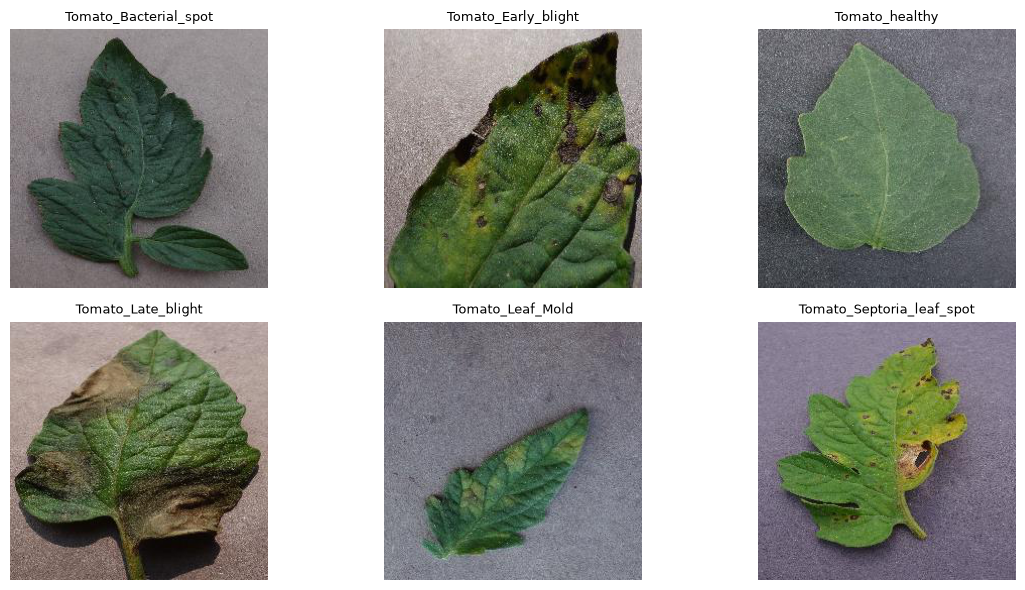

In [4]:
import matplotlib.pyplot as plt
from PIL import Image
import os

train_dir = "data_tomato/train"
classes = os.listdir(train_dir)

plt.figure(figsize=(12, 6))
for i, class_name in enumerate(classes[:6]):  # just first 6 classes for now
    class_folder = os.path.join(train_dir, class_name)
    img_name = os.listdir(class_folder)[0]
    img_path = os.path.join(class_folder, img_name)
    img = Image.open(img_path)

    plt.subplot(2, 3, i+1)
    plt.imshow(img)
    plt.title(class_name, fontsize=9)
    plt.axis("off")

plt.tight_layout()
plt.show()

In [5]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

img_size = (128, 128)
batch_size = 32

train_datagen = ImageDataGenerator(rescale=1./255)
val_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    "data_tomato/train",
    target_size=img_size,
    batch_size=batch_size,
    class_mode="categorical"
)

val_generator = val_datagen.flow_from_directory(
    "data_tomato/val",
    target_size=img_size,
    batch_size=batch_size,
    class_mode="categorical"
)

Found 12804 images belonging to 10 classes.
Found 3207 images belonging to 10 classes.


## 4. Model Architecture

In [6]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

model = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(128,128,3)),
    MaxPooling2D(2,2),

    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Conv2D(128, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(10, activation='softmax')
])

model.summary()

C:\Users\abdul\.conda\envs\project_pd\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,305,930 (12.61 MB)

 Trainable params: 3,305,930 (12.61 MB)

 Non-trainable params: 0 (0.00 B)

In [7]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

## 5. Training

In [8]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

checkpoint = ModelCheckpoint(
    "best_model.keras",
    monitor='val_accuracy',
    save_best_only=True
)

history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=15,
    callbacks=[early_stop, checkpoint]
)

Epoch 1/15
401/401 ━━━━━━━━━━━━━━━━━━━━ 110s 270ms/step - accuracy: 0.5475 - loss: 1.3087 - val_accuracy: 0.7088 - val_loss: 0.8555
Epoch 2/15
401/401 ━━━━━━━━━━━━━━━━━━━━ 53s 133ms/step - accuracy: 0.7288 - loss: 0.7857 - val_accuracy: 0.8416 - val_loss: 0.4623
Epoch 3/15
401/401 ━━━━━━━━━━━━━━━━━━━━ 51s 126ms/step - accuracy: 0.7886 - loss: 0.6219 - val_accuracy: 0.8650 - val_loss: 0.3917
Epoch 4/15
401/401 ━━━━━━━━━━━━━━━━━━━━ 51s 126ms/step - accuracy: 0.8233 - loss: 0.5138 - val_accuracy: 0.8815 - val_loss: 0.3422
Epoch 5/15
401/401 ━━━━━━━━━━━━━━━━━━━━ 50s 126ms/step - accuracy: 0.8397 - loss: 0.4689 - val_accuracy: 0.8849 - val_loss: 0.3464
Epoch 6/15
401/401 ━━━━━━━━━━━━━━━━━━━━ 51s 126ms/step - accuracy: 0.8619 - loss: 0.3917 - val_accuracy: 0.8996 - val_loss: 0.2890
Epoch 7/15
401/401 ━━━━━━━━━━━━━━━━━━━━ 51s 126ms/step - accuracy: 0.8690 - loss: 0.3692 - val_accuracy: 0.9055 - val_loss: 0.2583
Epoch 8/15
401/401 ━━━━━━━━━━━━━━━━━━━━ 52s 129ms/step - accuracy: 0.8875 - loss: 

## 6. Results & Evaluation

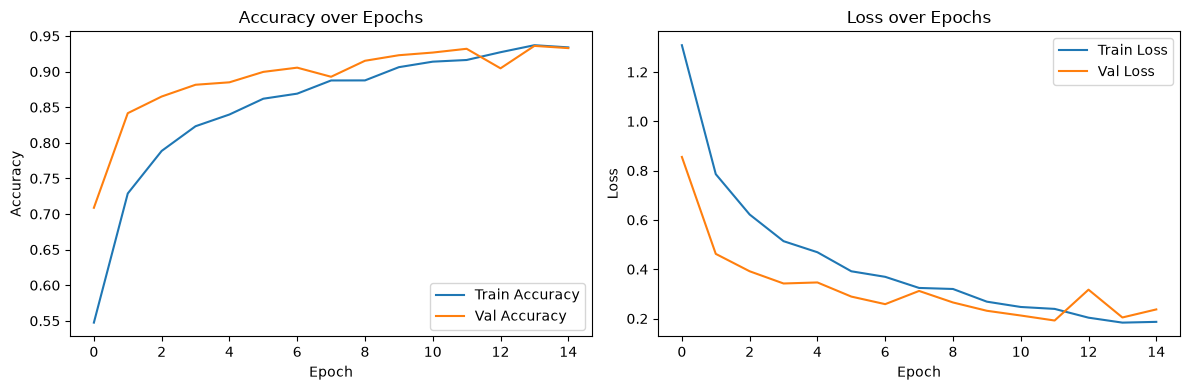

In [9]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Accuracy over Epochs')

plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.title('Loss over Epochs')

plt.tight_layout()
plt.savefig("training_history.png")
plt.show()

Found 3207 images belonging to 10 classes.
101/101 ━━━━━━━━━━━━━━━━━━━━ 4s 43ms/step


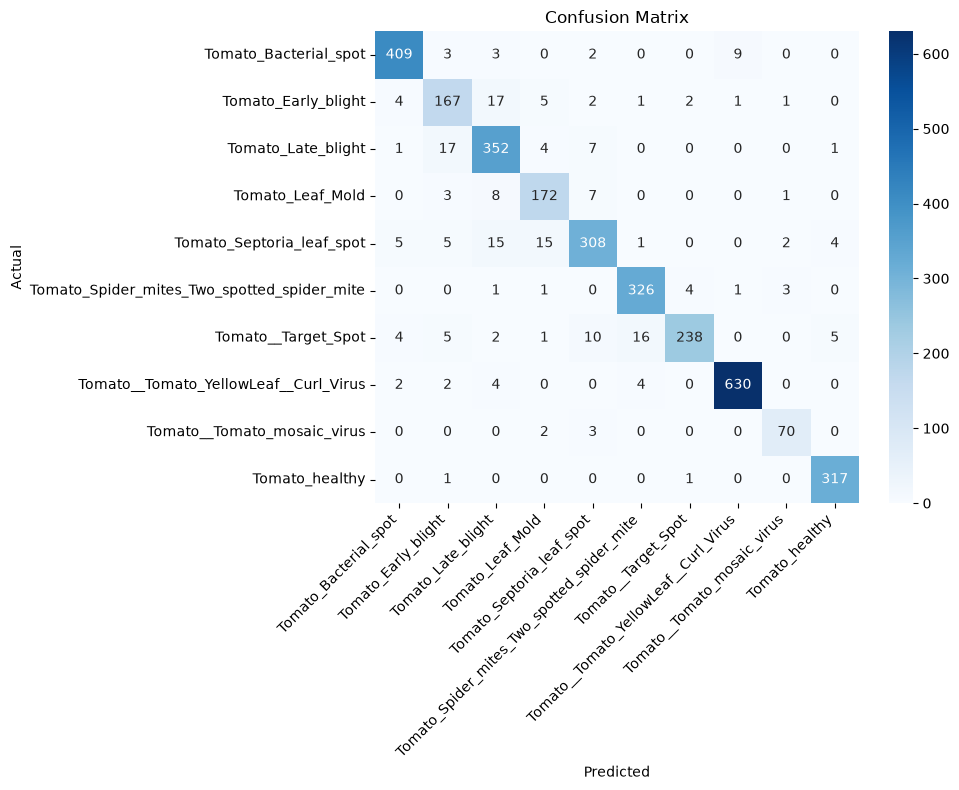

                                             precision    recall  f1-score   support

                      Tomato_Bacterial_spot       0.96      0.96      0.96       426
                        Tomato_Early_blight       0.82      0.83      0.83       200
                         Tomato_Late_blight       0.88      0.92      0.90       382
                           Tomato_Leaf_Mold       0.86      0.90      0.88       191
                  Tomato_Septoria_leaf_spot       0.91      0.87      0.89       355
Tomato_Spider_mites_Two_spotted_spider_mite       0.94      0.97      0.95       336
                        Tomato__Target_Spot       0.97      0.85      0.90       281
      Tomato__Tomato_YellowLeaf__Curl_Virus       0.98      0.98      0.98       642
                Tomato__Tomato_mosaic_virus       0.91      0.93      0.92        75
                             Tomato_healthy       0.97      0.99      0.98       319

                                   accuracy                    

In [12]:
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

eval_datagen = ImageDataGenerator(rescale=1./255)

eval_generator = eval_datagen.flow_from_directory(
    "data_tomato/val",
    target_size=img_size,
    batch_size=batch_size,
    class_mode="categorical",
    shuffle=False   # critical: keeps order matching val_generator.classes
)

predictions = model.predict(eval_generator)
predicted_classes = np.argmax(predictions, axis=1)
true_classes = eval_generator.classes
class_labels = list(eval_generator.class_indices.keys())

cm = confusion_matrix(true_classes, predicted_classes)

plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=class_labels, yticklabels=class_labels, cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig("confusion_matrix.png")
plt.show()

print(classification_report(true_classes, predicted_classes, target_names=class_labels))

In [13]:
model.save("tomato_disease_model.keras")
print("Model saved.")

Model saved.


## 7. Demo: Predict a Single Image

In [14]:
from tensorflow.keras.preprocessing import image


def predict_image(img_path, model, class_labels):
    img = image.load_img(img_path, target_size=(128, 128))
    img_array = image.img_to_array(img) / 255.0
    img_array = np.expand_dims(img_array, axis=0)

    prediction = model.predict(img_array)
    predicted_class = class_labels[np.argmax(prediction)]
    confidence = np.max(prediction) * 100

    plt.imshow(img)
    plt.axis('off')
    plt.title(f"Prediction: {predicted_class} ({confidence:.1f}% confidence)")
    plt.show()

    return predicted_class, confidence

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step


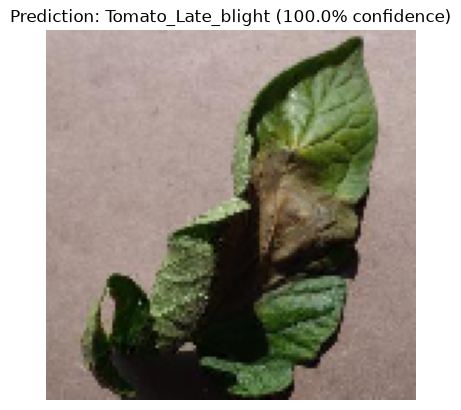

('Tomato_Late_blight', np.float32(100.0))

In [15]:
import os

test_class = "Tomato_Late_blight"
test_folder = os.path.join("data_tomato/val", test_class)
test_image_name = os.listdir(test_folder)[0]
test_image_path = os.path.join(test_folder, test_image_name)

predict_image(test_image_path, model, class_labels)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step


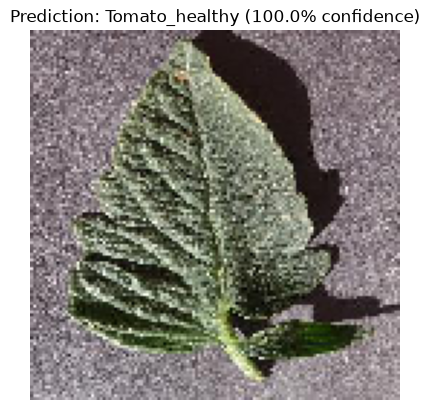

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step


<Figure size 640x480 with 0 Axes>

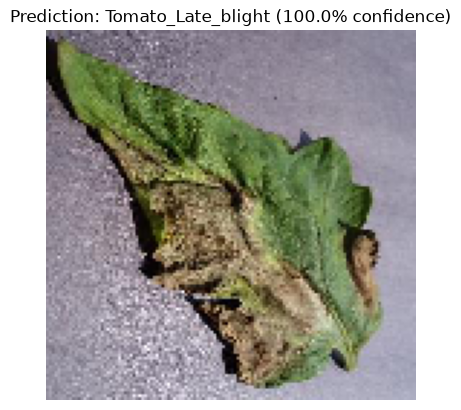

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step


<Figure size 640x480 with 0 Axes>

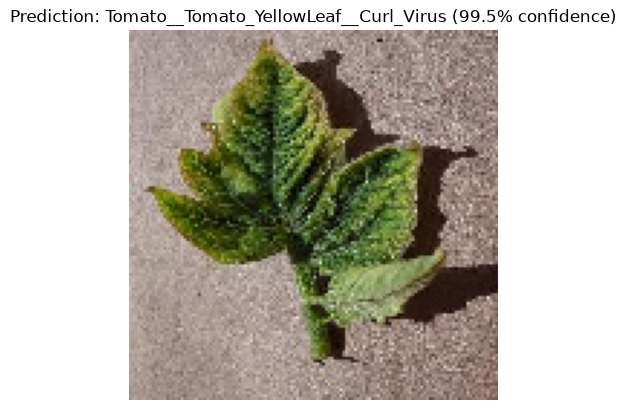

<Figure size 640x480 with 0 Axes>

In [16]:
import random

example_classes = ["Tomato_healthy", "Tomato_Late_blight", "Tomato__Tomato_YellowLeaf__Curl_Virus"]

for i, cls in enumerate(example_classes):
    folder = os.path.join("data_tomato/val", cls)
    img_name = random.choice(os.listdir(folder))
    img_path = os.path.join(folder, img_name)

    plt.figure()
    predicted_class, confidence = predict_image(img_path, model, class_labels)
    plt.savefig(f"example_prediction_{i+1}.png")